# 1. Conceitos Básicos

As equações diferenciais surgem quando procuramos determinar uma função a partir de informações sobre suas derivadas.

Em um problema algébrico, a incógnita é geralmente um número. Por exemplo,

$$
x^2-3x+2=0.
$$

Em uma equação diferencial, a incógnita é uma **função**.

Por exemplo,

$$
y'(x)=y(x)
$$

é uma equação cuja incógnita é uma função  y  . Resolver a equação significa determinar quais funções possuem a propriedade de serem iguais à sua própria derivada.

## 1.1 Equações diferenciais ordinárias

Uma **equação diferencial** é uma relação envolvendo uma função desconhecida e uma ou mais de suas derivadas.

Se a função desconhecida depende de uma única variável independente, temos uma **equação diferencial ordinária (EDO)**.

De modo geral, uma EDO pode ser escrita na forma

$$
F\left(x,y,y',y'',\ldots,y^{(n)}\right)=0.
$$

São exemplos:

$$
y'+xy=0,
$$

$$
y''+y'+x=\cos x,
$$

e

$$
(x^2+y^2)\,dx-(x+y)\,dy=0.
$$

Neste curso estaremos interessados principalmente em compreender três questões:

1. **Quais funções satisfazem uma determinada equação diferencial?**
2. **Como podemos encontrar essas funções?**
3. **Que propriedades das soluções podemos conhecer mesmo quando não conseguimos escrevê-las explicitamente?**

A terceira pergunta será particularmente importante ao longo do curso.

## 1.2 Ordem de uma equação diferencial

A **ordem** de uma equação diferencial é a ordem da derivada de maior ordem que aparece na equação.

Por exemplo,

$$
y'+xy=e^x
$$

é uma EDO de primeira ordem, enquanto

$$
y''+p(x)y=0
$$

é uma EDO de segunda ordem.

Já

$$
y^{(4)}-xy''=x^2
$$

é uma EDO de quarta ordem.

> **Observação.** A ordem da equação é uma propriedade da derivada de maior ordem presente e não do grau das expressões que aparecem na equação.

Por exemplo,

$$
(y')^5+y=0
$$

continua sendo uma equação diferencial de **primeira ordem**.

## 1.3 O que significa resolver uma EDO?

Considere uma equação

$$
F\left(x,y,y',\ldots,y^{(n)}\right)=0.
$$

Uma função

$$
y=\phi(x)
$$

é uma **solução** da equação em um intervalo  I   quando, após substituirmos

$$
y=\phi(x),\qquad
y'=\phi'(x),\qquad
\ldots,\qquad
y^{(n)}=\phi^{(n)}(x),
$$

a equação é satisfeita para todo  x\in I  .

### Exemplo 1

Verifique que

$$
y(x)=\sin x+\cos x
$$

é solução de

$$
y''+y=0.
$$

Temos

$$
y'(x)=\cos x-\sin x
$$

e

$$
y''(x)=-\sin x-\cos x.
$$

Portanto,

$$
y''+y
=
-\sin x-\cos x+\sin x+\cos x
=0.
$$

Logo,

$$
\boxed{y(x)=\sin x+\cos x}
$$

é uma solução da equação.

Esse exemplo ilustra uma distinção importante:

**encontrar uma solução** e **verificar uma solução** são problemas diferentes.

Se alguém nos fornece uma função candidata, normalmente podemos verificar diretamente se ela é solução. Encontrar a solução sem conhecê-la previamente é o problema central da integração de uma equação diferencial.

## 1.4 Verificação simbólica com Python

Podemos usar computação simbólica para realizar a mesma verificação.

In [ ]:
import sympy as sp

x = sp.symbols('x')

y = sp.sin(x) + sp.cos(x)

sp.simplify(sp.diff(y, x, 2) + y)

0

O resultado esperado é `0`. O computador não está, neste caso, **resolvendo** a equação diferencial. Ele está apenas verificando simbolicamente que a função proposta satisfaz a equação.

Experimente agora outras funções:

In [ ]:
candidatas = [
    sp.sin(x),
    sp.cos(x),
    sp.exp(x),
    x**2
]

for y in candidatas:
    resultado = sp.simplify(sp.diff(y, x, 2) + y)
    print(f"y = {str(y):15}  ->  y'' + y = {resultado}")

y = sin(x)           ->  y'' + y = 0
y = cos(x)           ->  y'' + y = 0
y = exp(x)           ->  y'' + y = 2*exp(x)
y = x**2             ->  y'' + y = x**2 + 2


**Pergunta:** quais dessas funções são soluções de

$$
y''+y=0?
$$

## 1.5 Curvas integrais

O gráfico de uma solução de uma equação diferencial é chamado de **curva integral** da equação.

Considere a EDO

$$
y'=1.
$$

Uma família de soluções é

$$
y=x+C,
$$

onde  C\in\mathbb{R}  .

De fato,

$$
\frac{d}{dx}(x+C)=1.
$$

Cada valor de  C   produz uma solução diferente e, portanto, uma curva integral diferente.

Vamos visualizar essa família.

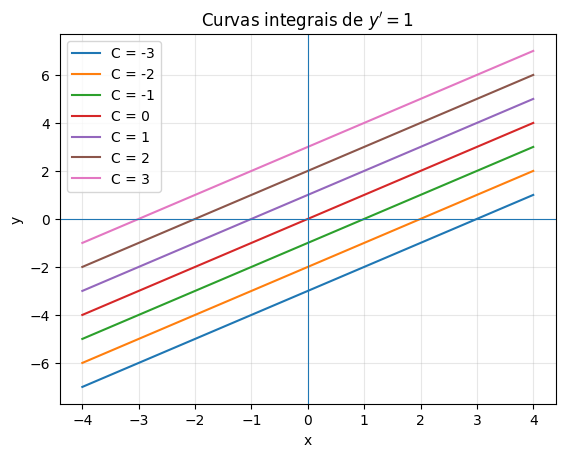

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

x = np.linspace(-4, 4, 400)

for C in [-3, -2, -1, 0, 1, 2, 3]:
    y = x + C
    plt.plot(x, y, label=f"C = {C}")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Curvas integrais de $y'=1$")
plt.grid(alpha=0.3)
plt.legend()
plt.show()

Geometricamente, a equação

$$
y'=1
$$

impõe que a curva solução tenha inclinação igual a  1   em todos os seus pontos.

Por isso, suas curvas integrais são retas paralelas.

## 1.6 Solução geral e solução particular

Para uma equação diferencial de primeira ordem,

$$
y'=f(x,y),
$$

é comum que as soluções apareçam formando uma família dependente de uma constante arbitrária:

$$
y=\phi(x,C).
$$

Chamamos essa família de **solução geral** quando ela representa a família de soluções da equação considerada.

Uma escolha específica de  C   fornece uma **solução particular**.

No exemplo

$$
y'=1,
$$

temos

$$
y=x+C.
$$

Se exigirmos adicionalmente que

$$
y(0)=0,
$$

então  C=0  , e a solução particular é

$$
\boxed{y=x}.
$$

Mais geralmente, se impusermos

$$
y(x_0)=y_0,
$$

obtemos

$$
C=y_0-x_0,
$$

e

$$
\boxed{y=x+y_0-x_0}.
$$

Observe a interpretação geométrica:

> dentre todas as curvas integrais da equação, a condição inicial seleciona aquela que passa pelo ponto  (x_0,y_0)  .

## 1.7 Um segundo exemplo

Considere

$$
y'-y=0.
$$

A família

$$
y=Ce^x
$$

é uma família de soluções, pois

$$
y'=Ce^x
$$

e, portanto,

$$
y'-y=Ce^x-Ce^x=0.
$$

Vamos visualizar algumas dessas curvas.

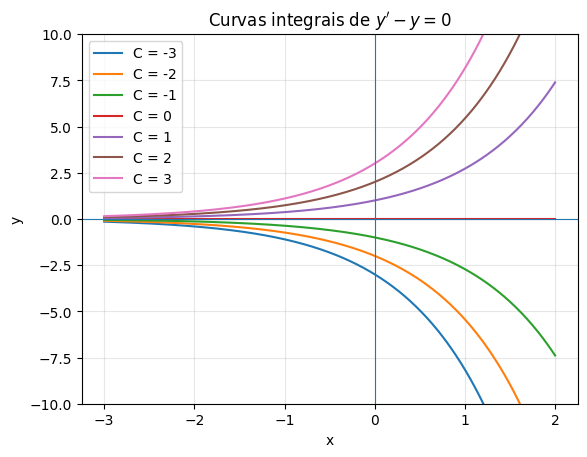

In [ ]:
x = np.linspace(-3, 2, 400)

for C in [-3, -2, -1, 0, 1, 2, 3]:
    y = C*np.exp(x)
    plt.plot(x, y, label=f"C = {C}")

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel("x")
plt.ylabel("y")
plt.title(r"Curvas integrais de $y'-y=0$")
plt.grid(alpha=0.3)
plt.ylim(-10, 10)
plt.legend()
plt.show()

Se impusermos

$$
y(1)=-1,
$$

teremos

$$
Ce=-1,
$$

logo

$$
C=-e^{-1}.
$$

Portanto,

$$
\boxed{y=-e^{x-1}}.
$$

Essa é a curva integral que passa pelo ponto

$$
(1,-1).
$$

## 1.8 Soluções implícitas

Nem sempre é conveniente — ou mesmo possível — escrever uma solução explicitamente na forma

$$
y=\phi(x).
$$

Uma relação

$$
\Phi(x,y,C)=0
$$

pode definir implicitamente uma família de soluções.

Nesse caso, dizemos que a relação fornece uma **integral geral** da equação diferencial.

Para um valor particular de  C  ,

$$
\Phi(x,y,C_0)=0
$$

define uma **integral particular**.

Portanto, resolver uma equação diferencial não significa necessariamente obter uma fórmula explícita para  y  .

## 1.9 O problema de valor inicial

Considere novamente uma equação diferencial de primeira ordem,

$$
y'=f(x,y).
$$

Podemos procurar não uma solução qualquer, mas uma solução que satisfaça

$$
y(x_0)=y_0.
$$

O problema

$$
\boxed{
\begin{cases}
y'=f(x,y),\\
y(x_0)=y_0
\end{cases}}
$$

é chamado de **problema de valor inicial** ou **problema de Cauchy**.

Geometricamente, estamos procurando uma curva integral que passe pelo ponto

$$
(x_0,y_0).
$$

Isso conduz imediatamente a duas perguntas fundamentais:

**Existência:** existe uma curva integral passando por  (x_0,y_0)  ?

**Unicidade:** existe apenas uma?

Essas perguntas são logicamente anteriores à pergunta de como calcular a solução.

## 1.10 Existência e unicidade

Considere

$$
y'=f(x,y),
\qquad
y(x_0)=y_0.
$$

Um resultado básico afirma que, se  f   e sua derivada parcial

$$
\frac{\partial f}{\partial y}
$$

são contínuas em uma região contendo  (x_0,y_0)  , então existe, ao menos localmente, uma única solução do problema de valor inicial.

Em outras palavras, sob essas hipóteses, por cada ponto da região passa localmente **uma única curva integral**.

Uma equação diferencial

$$
y'=f(x,y)
$$

atribui a cada ponto  (x,y)   uma inclinação  f(x,y)  . Sob condições adequadas de regularidade, essas inclinações organizam-se em curvas integrais que não podem se cruzar.

## 1.11 Quando a unicidade falha

Considere agora

$$
y'=2\sqrt{|y|}.
$$

A função

$$
y(x)=0
$$

é claramente uma solução.

Mas também existem soluções que passam pelo ponto  (0,0)   e depois se afastam do eixo  x  .

Para

$$
f(x,y)=2\sqrt{|y|},
$$

a função  f   é contínua, mas

$$
\frac{\partial f}{\partial y}
$$

não é contínua em  y=0  .

Assim, a hipótese suficiente de unicidade deixa de valer sobre o eixo  x  .

> A falha das hipóteses de um teorema de unicidade não implica, por si só, que não exista unicidade. Significa apenas que aquele teorema não a garante.

## 1.12 A visão geométrica

Até agora escrevemos uma equação de primeira ordem como

$$
y'=f(x,y).
$$

Mas

$$
y'=\frac{dy}{dx}
$$

representa a inclinação da reta tangente à curva solução.

Assim, a equação diferencial determina, em cada ponto  (x,y)  , uma direção:

$$
\frac{dy}{dx}=f(x,y).
$$

Podemos imaginar o plano preenchido por pequenos segmentos de reta, cada um com inclinação  f(x,y)  .

As soluções da equação diferencial devem seguir essas direções.

Essa construção é chamada de **campo de direções**.

Ela fornece uma maneira de compreender qualitativamente as soluções de uma equação diferencial **antes mesmo de resolvê-la**.

E será exatamente esse o ponto de partida da próxima seção.

# Exercícios

### Exercício 1

Determine a ordem de cada equação:

$$
y''+3y'-2y=0,
$$

$$
(y')^3+x^2y=1,
$$

$$
y^{(5)}+xy''=\sin x.
$$

### Exercício 2

Verifique diretamente que

$$
y=e^{-2x}
$$

é solução de

$$
y'+2y=0.
$$

Faça também a verificação usando `SymPy`.

### Exercício 3

Mostre que

$$
y=C\cos x
$$

é uma família de soluções de

$$
y'+y\tan x=0
$$

nos intervalos em que a equação está definida.

### Exercício 4

Mostre que

$$
y=-\frac{1}{3x+C}
$$

é uma família de soluções de

$$
y'=3y^2.
$$

Determine a solução que satisfaz

$$
y(0)=-1.
$$

### Exercício 5

Considere

$$
y'=y.
$$

1. Verifique que  y=Ce^x   é uma família de soluções.
2. Determine a solução que satisfaz  y(0)=2  .
3. Determine a solução que satisfaz  y(2)=1  .
4. Represente graficamente essas duas soluções juntamente com outras curvas da família.

### Exercício 6

Considere o problema de valor inicial

$$
\begin{cases}
y'=xy,\\
y(0)=1.
\end{cases}
$$

Sem tentar ainda resolver a equação, responda:

1. Qual é o valor de  y'(0)  ?
2. Se a solução passar pelo ponto  (1,2)  , qual deverá ser sua inclinação nesse ponto?
3. Qual é a inclinação de qualquer solução sobre o eixo  y  ?
4. O que acontece com a inclinação sobre o eixo  x  ?

## Para pensar

Uma equação diferencial não nos fornece diretamente uma curva. Ela fornece uma **regra local**:

$$
(x,y)\longmapsto f(x,y).
$$

Essa regra determina a inclinação que uma possível solução deve possuir ao passar por cada ponto.

Como reconstruir as curvas a partir dessa informação local?

Na próxima seção estudaremos uma das primeiras respostas geométricas a essa pergunta:

# **o método das isóclinas.**